In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [8]:

# 1. CARGAR DATASET
df = pd.read_csv("dataset.csv", sep=",")

# Seleccionar
select_letras = df['image'].str.contains('Dataset_Letras', case=False, na=False)
select_palabras = df['image'].str.contains('Dataset_Palabras', case=False, na=False)
select_oraciones = df['image'].str.contains('Dataset_Oraciones', case=False, na=False)

# Filtrar los DataFrames
df_letras = df[select_letras]
df_palabras = df[select_palabras]
df_oraciones = df[select_oraciones]

# 3. DIVIDIR CADA SUBSET EN TRAIN/VAL

# Letras: 93.3% train, 6.7% val
X1_train, X1_val, y1_train, y1_val = train_test_split(
    df_letras['image'].values,
    df_letras['label'].values,
    test_size=0.067,
    random_state=42,
    shuffle=True
)

# Palabras: 93.3% train, 6.7% val
X2_train, X2_val, y2_train, y2_val = train_test_split(
    df_palabras['image'].values,
    df_palabras['label'].values,
    test_size=0.067,
    random_state=42,
    shuffle=True
)

# Oraciones: 93.4% train, 6.6% val
X3_train, X3_val, y3_train, y3_val = train_test_split(
    df_oraciones['image'].values,
    df_oraciones['label'].values,
    test_size=0.066,
    random_state=42,
    shuffle=True
)

# Concatenar arrays de numpy
X_train = np.concatenate([X1_train, X2_train, X3_train])
y_train = np.concatenate([y1_train, y2_train, y3_train])

X_val = np.concatenate([X1_val, X2_val, X3_val])
y_val = np.concatenate([y1_val, y2_val, y3_val])

# 5. MEZCLAR EL DATASET FINAL (IMPORTANTE)

# Crear índices aleatorios
train_indices = np.random.permutation(len(X_train))
val_indices = np.random.permutation(len(X_val))

# Reordenar
X_train = X_train[train_indices]
y_train = y_train[train_indices]

X_val = X_val[val_indices]
y_val = y_val[val_indices]



In [9]:
#Hallar el tamaño de 100 x 100
def collate_fn(batch):
    batch.sort(key=lambda x: x[0].shape[-1], reverse=True)

    images = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    lengths = [b[2] for b in batch]

    max_width = max(img.shape[-1] for img in images)
    batch_size = len(images)
    img_height = images[0].shape[-2]
    padded = torch.zeros(batch_size, 1, img_height, max_width)

    for i, img in enumerate(images):
        w = img.shape[-1]
        padded[i, :, :, :w] = img

    concat_labels = torch.cat(labels)
    lengths = torch.tensor(lengths, dtype=torch.int32)

    return padded, concat_labels, lengths


Aqui modifique el tamaño que se utilizara las imagenes ya que aqui se modifica lo de imagenes nada mas

In [ ]:
# --- Dataset adaptado a imágenes ---
# PARTE 1: CARGA DE DATOS

class CargarDataset(Dataset):
    #El tamaño como tal se designa para la configuracion de las imagenes aqui donde se pone 100 x 100
    def __init__(self, X, y, alphabet, img_height=100, max_width=100):
        self.X = X  # rutas completas
        self.y = y  # textos
        self.img_height = img_height
        self.max_width = max_width
        self.alphabet = alphabet

        # Mapa carácter → índice
        self.char_to_idx = {char: i+1 for i, char in enumerate(alphabet)}
        self.idx_to_char = {i+1: char for i, char in enumerate(alphabet)}

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_path = self.X[idx]
        text = self.y[idx]

        # --- Cargar imagen ---
        img = Image.open(img_path).convert("L")

        w, h = img.size
        new_width = int(w * self.img_height / h)
        new_width = min(new_width, self.max_width)

        img = img.resize((new_width, self.img_height), Image.LANCZOS)

        img_array = np.array(img, dtype=np.float32) / 255.0
        img_tensor = torch.FloatTensor(img_array).unsqueeze(0)  # (1,H,W)

        # --- Codificar texto ---
        label = [self.char_to_idx[c] for c in text if c in self.char_to_idx]
        label_tensor = torch.LongTensor(label)

        return img_tensor, label_tensor, len(label_tensor)


alphabet = "abcdefghijklmnñopqrstuvwxyz0123456789., "

dataset = {
    "train": CargarDataset(X_train, y_train, alphabet),
    "val": CargarDataset(X_val, y_val, alphabet)
}

dataloader = {
    "train": DataLoader(dataset["train"], batch_size=8, shuffle=True, collate_fn=collate_fn),
    "val": DataLoader(dataset["val"], batch_size=8, shuffle=False, collate_fn=collate_fn)
}


In [11]:
# --- Función softmax ---
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)


In [12]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # --- EXTRACCIÓN DE FEATURES ---
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),   # H/2
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),   # H/4
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU()
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (B, 1, H, W)
        x = self.cnn(x)  # (B, 256, H', W')
        # Colapsar altura → H' se vuelve 1 con avg_pool
        x = nn.functional.adaptive_avg_pool2d(x, (1, x.size(3)))  # (B, 256, 1, W)
        x = x.squeeze(2)             # (B, 256, W)
        x = x.permute(2, 0, 1)       # (W, B, 256)  ← secuencia
        x = self.fc(x)               # (W, B, num_classes)
        return x


In [19]:
def fit(model, dataloaders, optimizer, epochs, device="cpu", early_stopping=15):
    model.to(device)

    criterion = nn.CTCLoss(blank=0, zero_infinity=True)

    history = {"loss": [], "val_loss": []}
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs+1):

        # ===========================
        #   ENTRENAMIENTO
        # ===========================
        model.train()
        train_losses = []

        for imgs, labels, label_lengths in dataloaders["train"]:
            imgs = imgs.to(device)
            labels = labels.to(device)
            label_lengths = label_lengths.to(device)

            outputs = model(imgs)  # (T, B, C)

            T, B, C = outputs.size()
            input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.int32).to(device)

            loss = criterion(outputs.log_softmax(2), labels, input_lengths, label_lengths)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        mean_train = sum(train_losses) / len(train_losses)
        history["loss"].append(mean_train)

        # ===========================
        #     VALIDACIÓN
        # ===========================
        model.eval()
        val_losses = []

        with torch.no_grad():
            for imgs, labels, label_lengths in dataloaders["val"]:
                imgs = imgs.to(device)
                labels = labels.to(device)
                label_lengths = label_lengths.to(device)

                outputs = model(imgs)
                T, B, C = outputs.size()
                input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.int32).to(device)

                loss = criterion(outputs.log_softmax(2), labels, input_lengths, label_lengths)
                val_losses.append(loss.item())

        mean_val = sum(val_losses) / len(val_losses)
        history["val_loss"].append(mean_val)

        print(f"Epoch {epoch}/{epochs} | Loss={mean_train:.4f} | Val={mean_val:.4f}")

        # ===========================
        #     EARLY STOPPING
        # ===========================
        if mean_val < best_val_loss:
            best_val_loss = mean_val
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping:
                print(f"\n⏳ EARLY STOPPING ACTIVADO en epoch {epoch}")
                break

    # cargar mejor modelo
    model.load_state_dict(torch.load("best_model.pt"))
    return history


In [20]:
num_classes = len(alphabet) + 1   # +1 para el blank de CTC

model = CNN(num_classes=num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = fit(model, dataloader, optimizer, epochs=100)

Epoch 1/100 | Loss=5.3789 | Val=3.2095
Epoch 2/100 | Loss=3.0934 | Val=3.0146
Epoch 3/100 | Loss=2.9787 | Val=3.0057
Epoch 4/100 | Loss=2.8746 | Val=2.8760
Epoch 5/100 | Loss=2.7608 | Val=2.7190
Epoch 6/100 | Loss=2.7196 | Val=2.6490
Epoch 7/100 | Loss=2.7107 | Val=2.6650
Epoch 8/100 | Loss=2.6463 | Val=2.8736
Epoch 9/100 | Loss=2.6853 | Val=3.0501
Epoch 10/100 | Loss=2.6280 | Val=2.7598
Epoch 11/100 | Loss=2.5987 | Val=2.6423
Epoch 12/100 | Loss=2.5453 | Val=2.6271
Epoch 13/100 | Loss=2.5799 | Val=2.5852
Epoch 14/100 | Loss=2.5410 | Val=2.6398
Epoch 15/100 | Loss=2.5497 | Val=2.5604
Epoch 16/100 | Loss=2.4969 | Val=2.6481
Epoch 17/100 | Loss=2.5123 | Val=2.5987
Epoch 18/100 | Loss=2.4631 | Val=2.5758
Epoch 19/100 | Loss=2.5145 | Val=2.5933
Epoch 20/100 | Loss=2.4460 | Val=2.6156
Epoch 21/100 | Loss=2.4098 | Val=2.6949
Epoch 22/100 | Loss=2.4227 | Val=2.5883
Epoch 23/100 | Loss=2.4307 | Val=2.6441
Epoch 24/100 | Loss=2.3698 | Val=2.5793
Epoch 25/100 | Loss=2.3804 | Val=2.7463
Epoch 26/

Predicción: a
Real: z
Incorrecto ❌


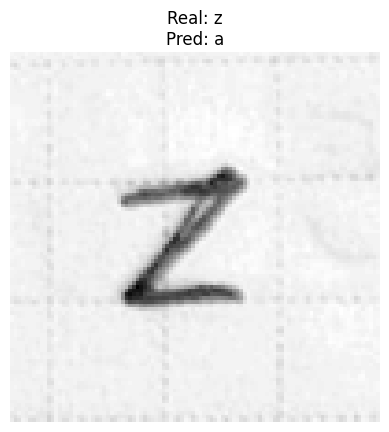

In [15]:
# --- Tomar un batch de validación ---
x_batch, y_batch, y_len = next(iter(dataloader["val"]))
batch_size = x_batch.size(0)

# --- Elegir una imagen aleatoria del batch ---
idx = torch.randint(0, batch_size, (1,)).item()
img = x_batch[idx:idx+1]
target_len = y_len[idx]
start_idx = y_len[:idx].sum() if idx > 0 else 0
target_seq = y_batch[start_idx:start_idx+target_len]

# --- Predicción con modelo corregido ---
model.eval()
with torch.no_grad():
    output = model(img)
    # Decodificación greedy CTC
    seq = torch.argmax(output[:,0], dim=1).cpu().numpy()
    text_pred, prev = "", -1
    for i in seq:
        if i != prev and i != 0:
            text_pred += alphabet[i-1]
        prev = i

    # Decodificar target real
    text_real = "".join([alphabet[i-1] for i in target_seq.cpu().numpy()])

# --- Mostrar resultado ---
print(f"Predicción: {text_pred}")
print(f"Real: {text_real}")
print("Correcto ✅" if text_pred == text_real else "Incorrecto ❌")

# --- Visualizar imagen ---
plt.imshow(img[0,0].cpu(), cmap='gray')
plt.title(f'Real: {text_real}\nPred: {text_pred}')
plt.axis('off')
plt.show()

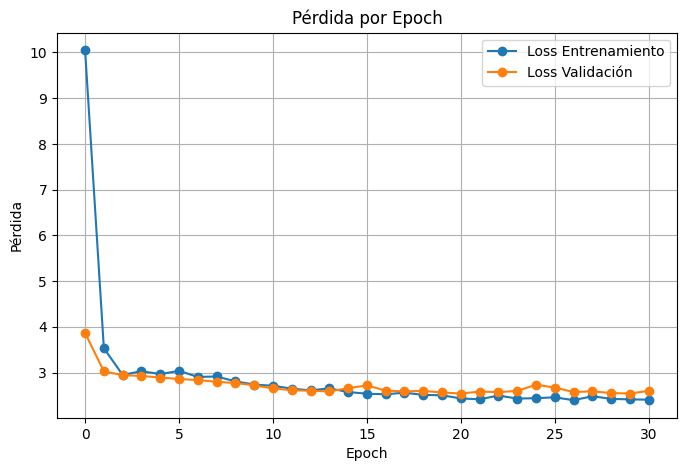

Precisión final de entrenamiento: 2.41%
Precisión final de validación: 2.60%


In [16]:

# Graficar pérdida
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Loss Entrenamiento', marker='o')
plt.plot(history['val_loss'], label='Loss Validación', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Pérdida')
plt.title('Pérdida por Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar precisión final por print
print(f"Precisión final de entrenamiento: {history['loss'][-1]:.2f}%")
print(f"Precisión final de validación: {history['val_loss'][-1]:.2f}%")


Aqui agrege mi nuevas letras para que se lee nuevo y diferentes


Predicción: a


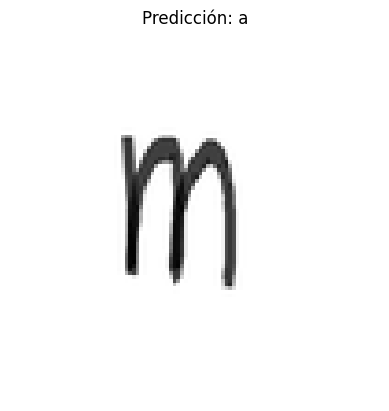

In [ ]:
# 1. Cargar y preparar imagen
ruta = "Imagenes_Extra/otra_letra.png"
img = Image.open(ruta).convert("L")

# Redimensionar (igual que tu Dataset)
w, h = img.size
altura = 100
nuevo_ancho = min(int(w * altura / h), 100)
img = img.resize((nuevo_ancho, altura), Image.LANCZOS)

# Convertir a tensor
img_array = np.array(img, dtype=np.float32) / 255.0
img_tensor = torch.FloatTensor(img_array).unsqueeze(0)  # (1, 100, ancho)

# Aplicar padding a 100
if nuevo_ancho < 100:
    pad = 100 - nuevo_ancho
    img_tensor = torch.nn.functional.pad(img_tensor, (0, pad, 0, 0))

# Añadir batch dimension
img_tensor = img_tensor.unsqueeze(0)  # (1, 1, 100, 100)
img_tensor = img_tensor.to('cpu')

# 4. Predicción
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    seq = torch.argmax(output[:,0], dim=1).cpu().numpy()
    text_pred, prev = "", -1
    for i in seq:
        if i != prev and i != 0:
            text_pred += alphabet[i-1]
        prev = i

print(f"\nPredicción: {text_pred}")

# 5. Visualizar
plt.imshow(img_tensor[0,0].cpu(), cmap='gray')
plt.title(f'Predicción: {text_pred}')
plt.axis('off')
plt.show()